# Customer Churn Prediction — Working with a Business Problem

**NeuroFive ML Track — Task 6**

Customer churn refers to customers who stop using a company's services. In this project, we analyze the Telco Customer Churn dataset to understand the factors associated with customer churn and build machine learning models to predict which customers are likely to leave.

The project includes:
- Exploratory Data Analysis (EDA)
- Data cleaning and preprocessing
- Handling categorical variables
- Training Decision Tree and Logistic Regression models
- Comparing model performance
- Analyzing the top features driving churn
- Creating a business-focused summary of the results

In [2]:
# Import required libraries and load the Telco Customer Churn dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load dataset
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Inspect dataset structure, data types, missing values, and basic statistics

print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
display(df.describe(include='all').T)

Dataset Shape: (7043, 21)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Clean the TotalCharges column and prepare the target variable

# Convert TotalCharges to numeric because it may contain blank spaces
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values after conversion
print("Missing values after conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Remove CustomerID because it does not help predict churn
df = df.drop('customerID', axis=1)

# Fill missing TotalCharges values with the median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Convert Churn into binary values
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("\nCleaned Dataset Shape:", df.shape)
df.head()

Missing values after conversion:
TotalCharges    11
dtype: int64

Cleaned Dataset Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn Percentage:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


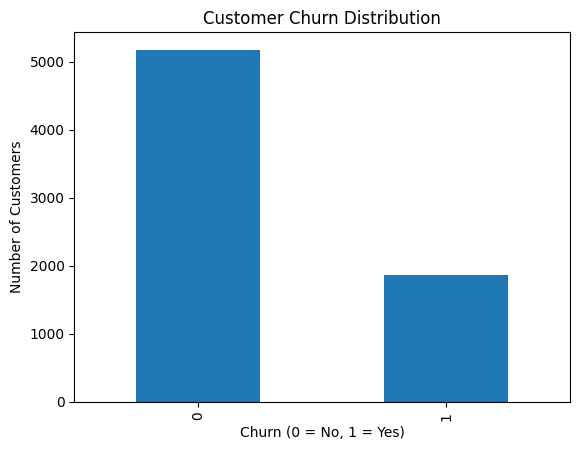


Churn Rate by Contract Type:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


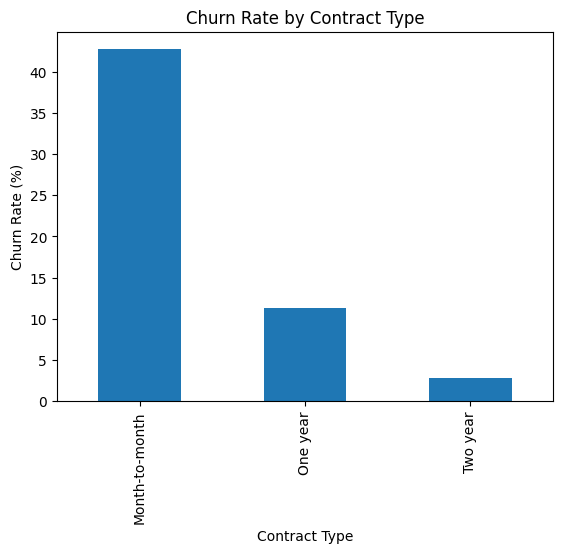


Average Tenure and Monthly Charges by Churn:


,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,37.57,61.27,2552.88
1,17.98,74.44,1531.80


In [5]:
# Explore churn distribution and important business features

print("Churn Distribution:")
print(df['Churn'].value_counts())

print("\nChurn Percentage:")
print((df['Churn'].value_counts(normalize=True) * 100).round(2))

# Plot churn distribution
df['Churn'].value_counts().plot(kind='bar')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

# Compare churn rate by contract type
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False) * 100

print("\nChurn Rate by Contract Type:")
print(contract_churn.round(2))

contract_churn.plot(kind='bar')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.show()

# Compare average numerical values by churn
print("\nAverage Tenure and Monthly Charges by Churn:")
display(df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(2))

In [6]:
# Separate features and target, then prepare numerical and categorical preprocessing

X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include='object').columns.tolist()
numerical_features = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical Features:", len(categorical_features))
print("Numerical Features:", len(numerical_features))

# Preprocessing for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Categorical Features: 15
Numerical Features: 4
Training Data: (5634, 19)
Testing Data: (1409, 19)


Decision Tree Accuracy: 72.82 %

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1035
           1       0.49      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



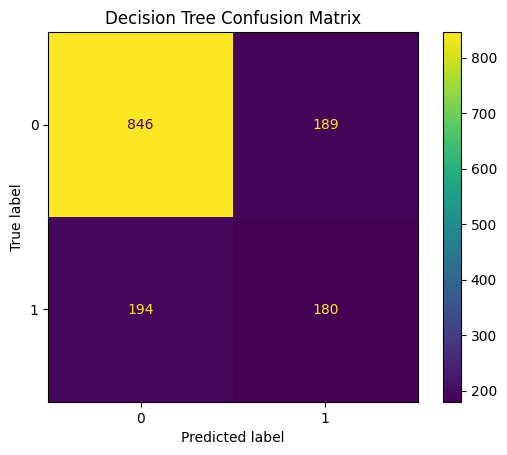

In [7]:
# Train a Decision Tree Classifier and evaluate its performance

decision_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

decision_tree_pipeline.fit(X_train, y_train)

# Predictions
dt_predictions = decision_tree_pipeline.predict(X_test)

# Evaluation
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, dt_predictions)
plt.title('Decision Tree Confusion Matrix')
plt.show()

Logistic Regression Accuracy: 73.81 %

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



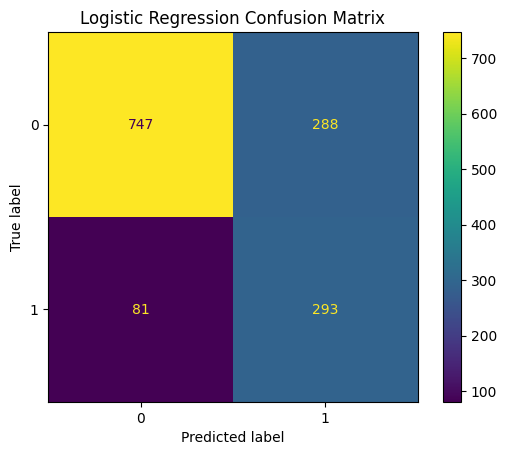

In [8]:
# Train a Logistic Regression model and evaluate its performance

logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

# Predictions
lr_predictions = logistic_pipeline.predict(X_test)

# Evaluation
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, lr_predictions)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

,Model,Accuracy (%)
0,Decision Tree,72.82
1,Logistic Regression,73.81


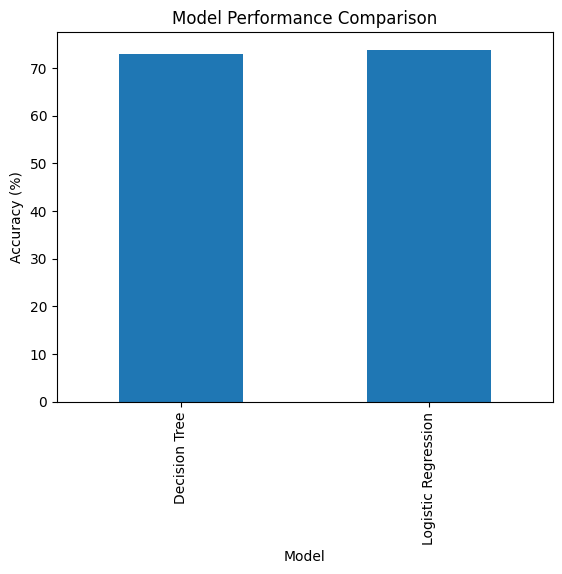

In [9]:
# Compare the performance of Decision Tree and Logistic Regression

comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression'],
    'Accuracy': [dt_accuracy, lr_accuracy]
})

comparison['Accuracy (%)'] = comparison['Accuracy'] * 100

display(comparison[['Model', 'Accuracy (%)']].round(2))

comparison.plot(
    x='Model',
    y='Accuracy (%)',
    kind='bar',
    legend=False
)

plt.title('Model Performance Comparison')
plt.ylabel('Accuracy (%)')
plt.xlabel('Model')
plt.show()

Top 10 Features Driving Churn:


,Feature,Importance
36,cat__Contract_Month-to-month,0.233961
2,num__MonthlyCharges,0.172623
3,num__TotalCharges,0.170300
1,num__tenure,0.103472
16,cat__InternetService_Fiber optic,0.041527
43,cat__PaymentMethod_Electronic check,0.019722
27,cat__TechSupport_No,0.017454
5,cat__gender_Male,0.017430
0,num__SeniorCitizen,0.014827
42,cat__PaymentMethod_Credit card (automatic),0.014319



Top 3 Features Driving Churn:


,Feature,Importance
36,cat__Contract_Month-to-month,0.233961
2,num__MonthlyCharges,0.172623
3,num__TotalCharges,0.170300


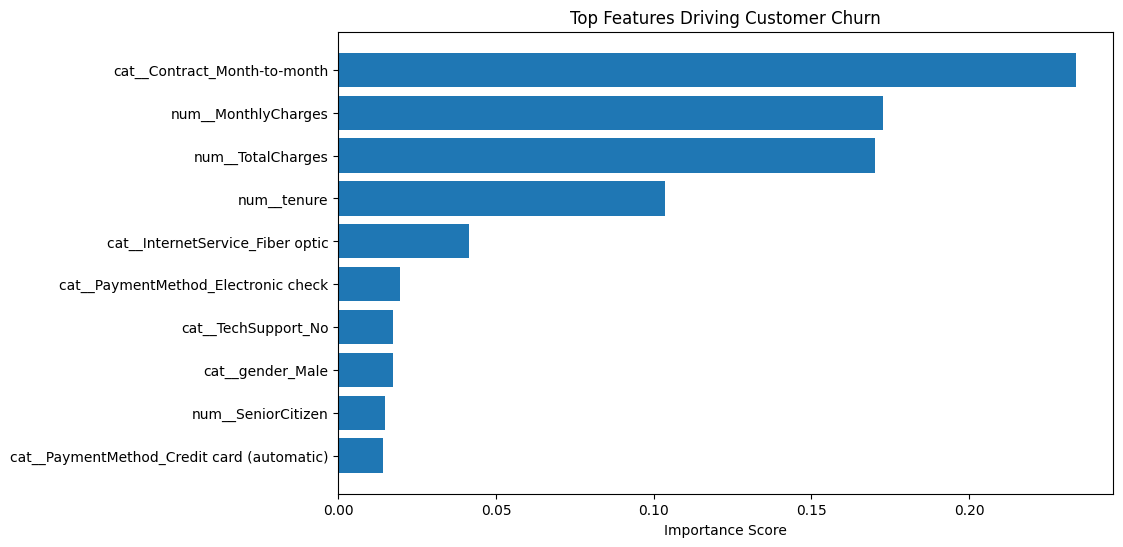

In [10]:
# Identify the three most important features according to the Decision Tree

# Get the trained Decision Tree model
tree_model = decision_tree_pipeline.named_steps['model']

# Get feature names after preprocessing
feature_names = decision_tree_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': tree_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top 10 Features Driving Churn:")
display(feature_importance.head(10))

print("\nTop 3 Features Driving Churn:")
display(feature_importance.head(3))

# Plot top 10 features
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance Score')
plt.title('Top Features Driving Customer Churn')
plt.gca().invert_yaxis()
plt.show()

# Business Summary

The analysis identified several important factors associated with customer churn, particularly related to customer contracts, service usage, and monthly costs. The dataset showed that churn is not evenly distributed, meaning there is some class imbalance that should be considered when evaluating the models.

Both the Decision Tree and Logistic Regression models were trained to predict customer churn, with their performance compared using accuracy and classification metrics. The Decision Tree model also helped identify the three most influential features affecting churn.

These findings can help the business identify customers who are more likely to leave and take preventive actions, such as offering better contract options, personalized discounts, or improved customer support. Future improvements could include hyperparameter tuning and additional techniques for handling class imbalance.